# Titulo: Interpolación lineal.
## Diplomado: Geoestadística y análisis espacial
## SciData
## Instructor: Alexis Adonai Morales Alberto


In [15]:
# Modulos

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.interpolate import griddata

In [16]:
# Configuración de google drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# Ruta completa del archivo

ruta_mapa = '/content/drive/MyDrive/SciData/GEOAES_25/Mapas/Mexico_mun/00mun'
ruta_data = '/content/drive/MyDrive/SciData/GEOAES_25/Bases/Pob_Mun_CPyV2020.csv'

In [18]:
# Cargar mapa

Mapa = gpd.read_file(ruta_mapa + '.shp')
Mapa.head(10)

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry
0,01001,01,001,Aguascalientes,"POLYGON ((2488980.227 1117358.447, 2489013.495..."
1,01008,01,008,San José de Gracia,"POLYGON ((2453326.553 1143576.423, 2453363.325..."
2,01011,01,011,San Francisco de los Romo,"POLYGON ((2483638.349 1120034.022, 2483946.175..."
3,01009,01,009,Tepezalá,"POLYGON ((2481826.447 1149055.253, 2481589.222..."
4,01007,01,007,Rincón de Romos,"POLYGON ((2476760.231 1150329.046, 2476783.634..."
5,01006,01,006,Pabellón de Arteaga,"POLYGON ((2473996.656 1129304.114, 2474217.809..."
6,01004,01,004,Cosío,"POLYGON ((2469550.852 1159302.643, 2469738.209..."
7,01005,01,005,Jesús María,"POLYGON ((2463657.764 1116053.82, 2463738.92 1..."
8,01010,01,010,El Llano,"POLYGON ((2496481.299 1116760.454, 2496691.232..."
9,01003,01,003,Calvillo,"POLYGON ((2429646.495 1120918.059, 2429711.746..."


In [19]:
# Cargar datos de población 2020

Data = pd.read_csv(ruta_data)

Data.head(10)

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,POBTOT
0,1,Aguascalientes,1,Aguascalientes,948990
1,1,Aguascalientes,2,Asientos,51536
2,1,Aguascalientes,3,Calvillo,58250
3,1,Aguascalientes,4,Cosío,17000
4,1,Aguascalientes,5,Jesús María,129929
5,1,Aguascalientes,6,Pabellón de Arteaga,47646
6,1,Aguascalientes,7,Rincón de Romos,57369
7,1,Aguascalientes,8,San José de Gracia,9552
8,1,Aguascalientes,9,Tepezalá,22485
9,1,Aguascalientes,10,El Llano,20853


In [20]:
# Transformación de las columnas al forma del mapa

Data['ENTIDAD'] = Data['ENTIDAD'].astype(str).str.zfill(2)
Data['MUN'] = Data['MUN'].astype(str).str.zfill(3)

Data[11:20]

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,POBTOT
11,02,Baja California,001,Ensenada,443807
12,02,Baja California,002,Mexicali,1049792
13,02,Baja California,003,Tecate,108440
14,02,Baja California,004,Tijuana,1922523
15,02,Baja California,005,Playas de Rosarito,126890
16,02,Baja California,006,San Quintín,117568
17,03,Baja California Sur,001,Comondú,73021
18,03,Baja California Sur,002,Mulegé,64022
19,03,Baja California Sur,003,La Paz,292241


In [21]:
# Unión de datos

Mapa = Mapa.merge(
    Data[['ENTIDAD', 'MUN', 'POBTOT']],
    left_on = ['CVE_ENT', 'CVE_MUN'],
    right_on = ['ENTIDAD', 'MUN'],
    how = 'left'
)

Mapa[10:22]

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,ENTIDAD,MUN,POBTOT
10,01002,01,002,Asientos,"POLYGON ((2493552.647 1142361.087, 2493586.6 1...",01,002,51536.0
11,02007,02,007,San Felipe,"MULTIPOLYGON (((1303929.109 2024125.252, 13040...",NaN,NaN,NaN
12,02003,02,003,Tecate,"POLYGON ((1108369.153 2349424.69, 1108488.649 ...",02,003,108440.0
13,02004,02,004,Tijuana,"MULTIPOLYGON (((1058853.778 2337446.07, 105884...",02,004,1922523.0
14,02001,02,001,Ensenada,"MULTIPOLYGON (((1208711.465 1871972.953, 12087...",02,001,443807.0
15,02006,02,006,San Quintín,"MULTIPOLYGON (((1313480.513 1831458.607, 13135...",02,006,117568.0
16,02005,02,005,Playas de Rosarito,"POLYGON ((1076736.333 2336649.366, 1076738.335...",02,005,126890.0
17,02002,02,002,Mexicali,"MULTIPOLYGON (((1288348.994 2246381.522, 12884...",02,002,1049792.0
18,03001,03,001,Comondú,"MULTIPOLYGON (((1493700.998 1422385.022, 14937...",03,001,73021.0
19,03008,03,008,Los Cabos,"MULTIPOLYGON (((1694656.344 1227647.637, 16946...",03,008,351111.0


In [22]:
# Cálculo del área de los polígonos

Mapa_proyectado = Mapa.to_crs(epsg = 3857)
Mapa_proyectado['area_m2'] = Mapa.area # Al área en M2
Mapa_proyectado['area_km2'] = Mapa_proyectado['area_m2']/10**6
Mapa_proyectado[['CVE_ENT', 'CVE_MUN', 'area_km2']]

,CVE_ENT,CVE_MUN,area_km2
0,01,001,1161.387798
1,01,008,792.172035
2,01,011,137.769453
3,01,009,229.661012
4,01,007,371.953212
...,...,...,...
2473,32,004,325.651276
2474,32,043,197.478110
2475,32,042,3593.564615
2476,32,014,4783.818783


In [23]:
# Unión de datos

Mapa = Mapa.merge(
    Mapa_proyectado[['CVE_ENT', 'CVE_MUN', 'area_km2']],
    left_on = ['CVE_ENT', 'CVE_MUN'],
    right_on = ['CVE_ENT', 'CVE_MUN'],
    how = 'left'
)
Mapa['POB_KM2'] = Mapa['POBTOT']/Mapa['area_km2']
Mapa[10:22]


,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,ENTIDAD,MUN,POBTOT,area_km2,POB_KM2
10,01002,01,002,Asientos,"POLYGON ((2493552.647 1142361.087, 2493586.6 1...",01,002,51536.0,542.442303,95.007339
11,02007,02,007,San Felipe,"MULTIPOLYGON (((1303929.109 2024125.252, 13040...",NaN,NaN,NaN,11063.217086,NaN
12,02003,02,003,Tecate,"POLYGON ((1108369.153 2349424.69, 1108488.649 ...",02,003,108440.0,2900.518701,37.386416
13,02004,02,004,Tijuana,"MULTIPOLYGON (((1058853.778 2337446.07, 105884...",02,004,1922523.0,1090.937294,1762.267190
14,02001,02,001,Ensenada,"MULTIPOLYGON (((1208711.465 1871972.953, 12087...",02,001,443807.0,13662.828278,32.482806
15,02006,02,006,San Quintín,"MULTIPOLYGON (((1313480.513 1831458.607, 13135...",02,006,117568.0,34097.244942,3.448021
16,02005,02,005,Playas de Rosarito,"POLYGON ((1076736.333 2336649.366, 1076738.335...",02,005,126890.0,513.145384,247.278849
17,02002,02,002,Mexicali,"MULTIPOLYGON (((1288348.994 2246381.522, 12884...",02,002,1049792.0,10078.266923,104.163941
18,03001,03,001,Comondú,"MULTIPOLYGON (((1493700.998 1422385.022, 14937...",03,001,73021.0,17532.625450,4.164864
19,03008,03,008,Los Cabos,"MULTIPOLYGON (((1694656.344 1227647.637, 16946...",03,008,351111.0,3517.574801,99.816214


## Centroides y proyección

In [25]:
# Centroides

x = Mapa.centroid.x.values
y = Mapa.centroid.y.values

# Valores

z = Mapa['POB_KM2'].values

In [27]:
# Separar obs y faltantes

mask_obs = ~np.isnan(z)

x_obs = x[mask_obs]
y_obs = y[mask_obs]
z_obs = z[mask_obs]

x_nan = x[~mask_obs]
y_nan = y[~mask_obs]

In [28]:
# Interpolación lineal SOLO para los NAN

z_pred_nan = griddata(
    points = (x_obs, y_obs),
    values = z_obs,
    xi = (x_nan, y_nan),
    method = 'linear'
)

In [29]:
# Opcional con nearest

mask_fail = np.isnan(z_pred_nan)

if mask_fail.any():
  z_pred_nan[mask_fail] = griddata(
      points = (x_obs, y_obs),
      values = z_obs,
      xi = (x_nan[mask_fail], y_nan[mask_fail]),
      method = 'nearest'
  )

In [31]:
# Reconstrucción del vector completo

z_complete = z.copy()
z_complete[~mask_obs] = z_pred_nan

Mapa['POB_km2_lineal'] = z_complete
Mapa['Tipo_dato'] = np.where(mask_obs, 'Observado', 'Imputado')

Mapa[11:22]


,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,ENTIDAD,MUN,POBTOT,area_km2,POB_KM2,POB_km2_lineal,Tipo_dato
11,02007,02,007,San Felipe,"MULTIPOLYGON (((1303929.109 2024125.252, 13040...",NaN,NaN,NaN,11063.217086,NaN,16.463268,Imputado
12,02003,02,003,Tecate,"POLYGON ((1108369.153 2349424.69, 1108488.649 ...",02,003,108440.0,2900.518701,37.386416,37.386416,Observado
13,02004,02,004,Tijuana,"MULTIPOLYGON (((1058853.778 2337446.07, 105884...",02,004,1922523.0,1090.937294,1762.267190,1762.267190,Observado
14,02001,02,001,Ensenada,"MULTIPOLYGON (((1208711.465 1871972.953, 12087...",02,001,443807.0,13662.828278,32.482806,32.482806,Observado
15,02006,02,006,San Quintín,"MULTIPOLYGON (((1313480.513 1831458.607, 13135...",02,006,117568.0,34097.244942,3.448021,3.448021,Observado
16,02005,02,005,Playas de Rosarito,"POLYGON ((1076736.333 2336649.366, 1076738.335...",02,005,126890.0,513.145384,247.278849,247.278849,Observado
17,02002,02,002,Mexicali,"MULTIPOLYGON (((1288348.994 2246381.522, 12884...",02,002,1049792.0,10078.266923,104.163941,104.163941,Observado
18,03001,03,001,Comondú,"MULTIPOLYGON (((1493700.998 1422385.022, 14937...",03,001,73021.0,17532.625450,4.164864,4.164864,Observado
19,03008,03,008,Los Cabos,"MULTIPOLYGON (((1694656.344 1227647.637, 16946...",03,008,351111.0,3517.574801,99.816214,99.816214,Observado
20,03003,03,003,La Paz,"MULTIPOLYGON (((1677351.228 1380621.554, 16773...",03,003,292241.0,15279.285152,19.126615,19.126615,Observado


In [32]:
# Valor interpolado de San Felipe, BC

11063.217086*16.463268

182136.70782899705

In [36]:
# Superficie interpolada

grid_x = np.linspace(x.min(), x.max(), 150)
grid_y = np.linspace(y.min(), y.max(), 150)
grid_X, grid_Y = np.meshgrid(grid_x, grid_y)

z_grid = griddata(
    points = (x_obs, y_obs),
    values = z_obs,
    xi = (grid_X, grid_Y),
    method = 'linear'
)

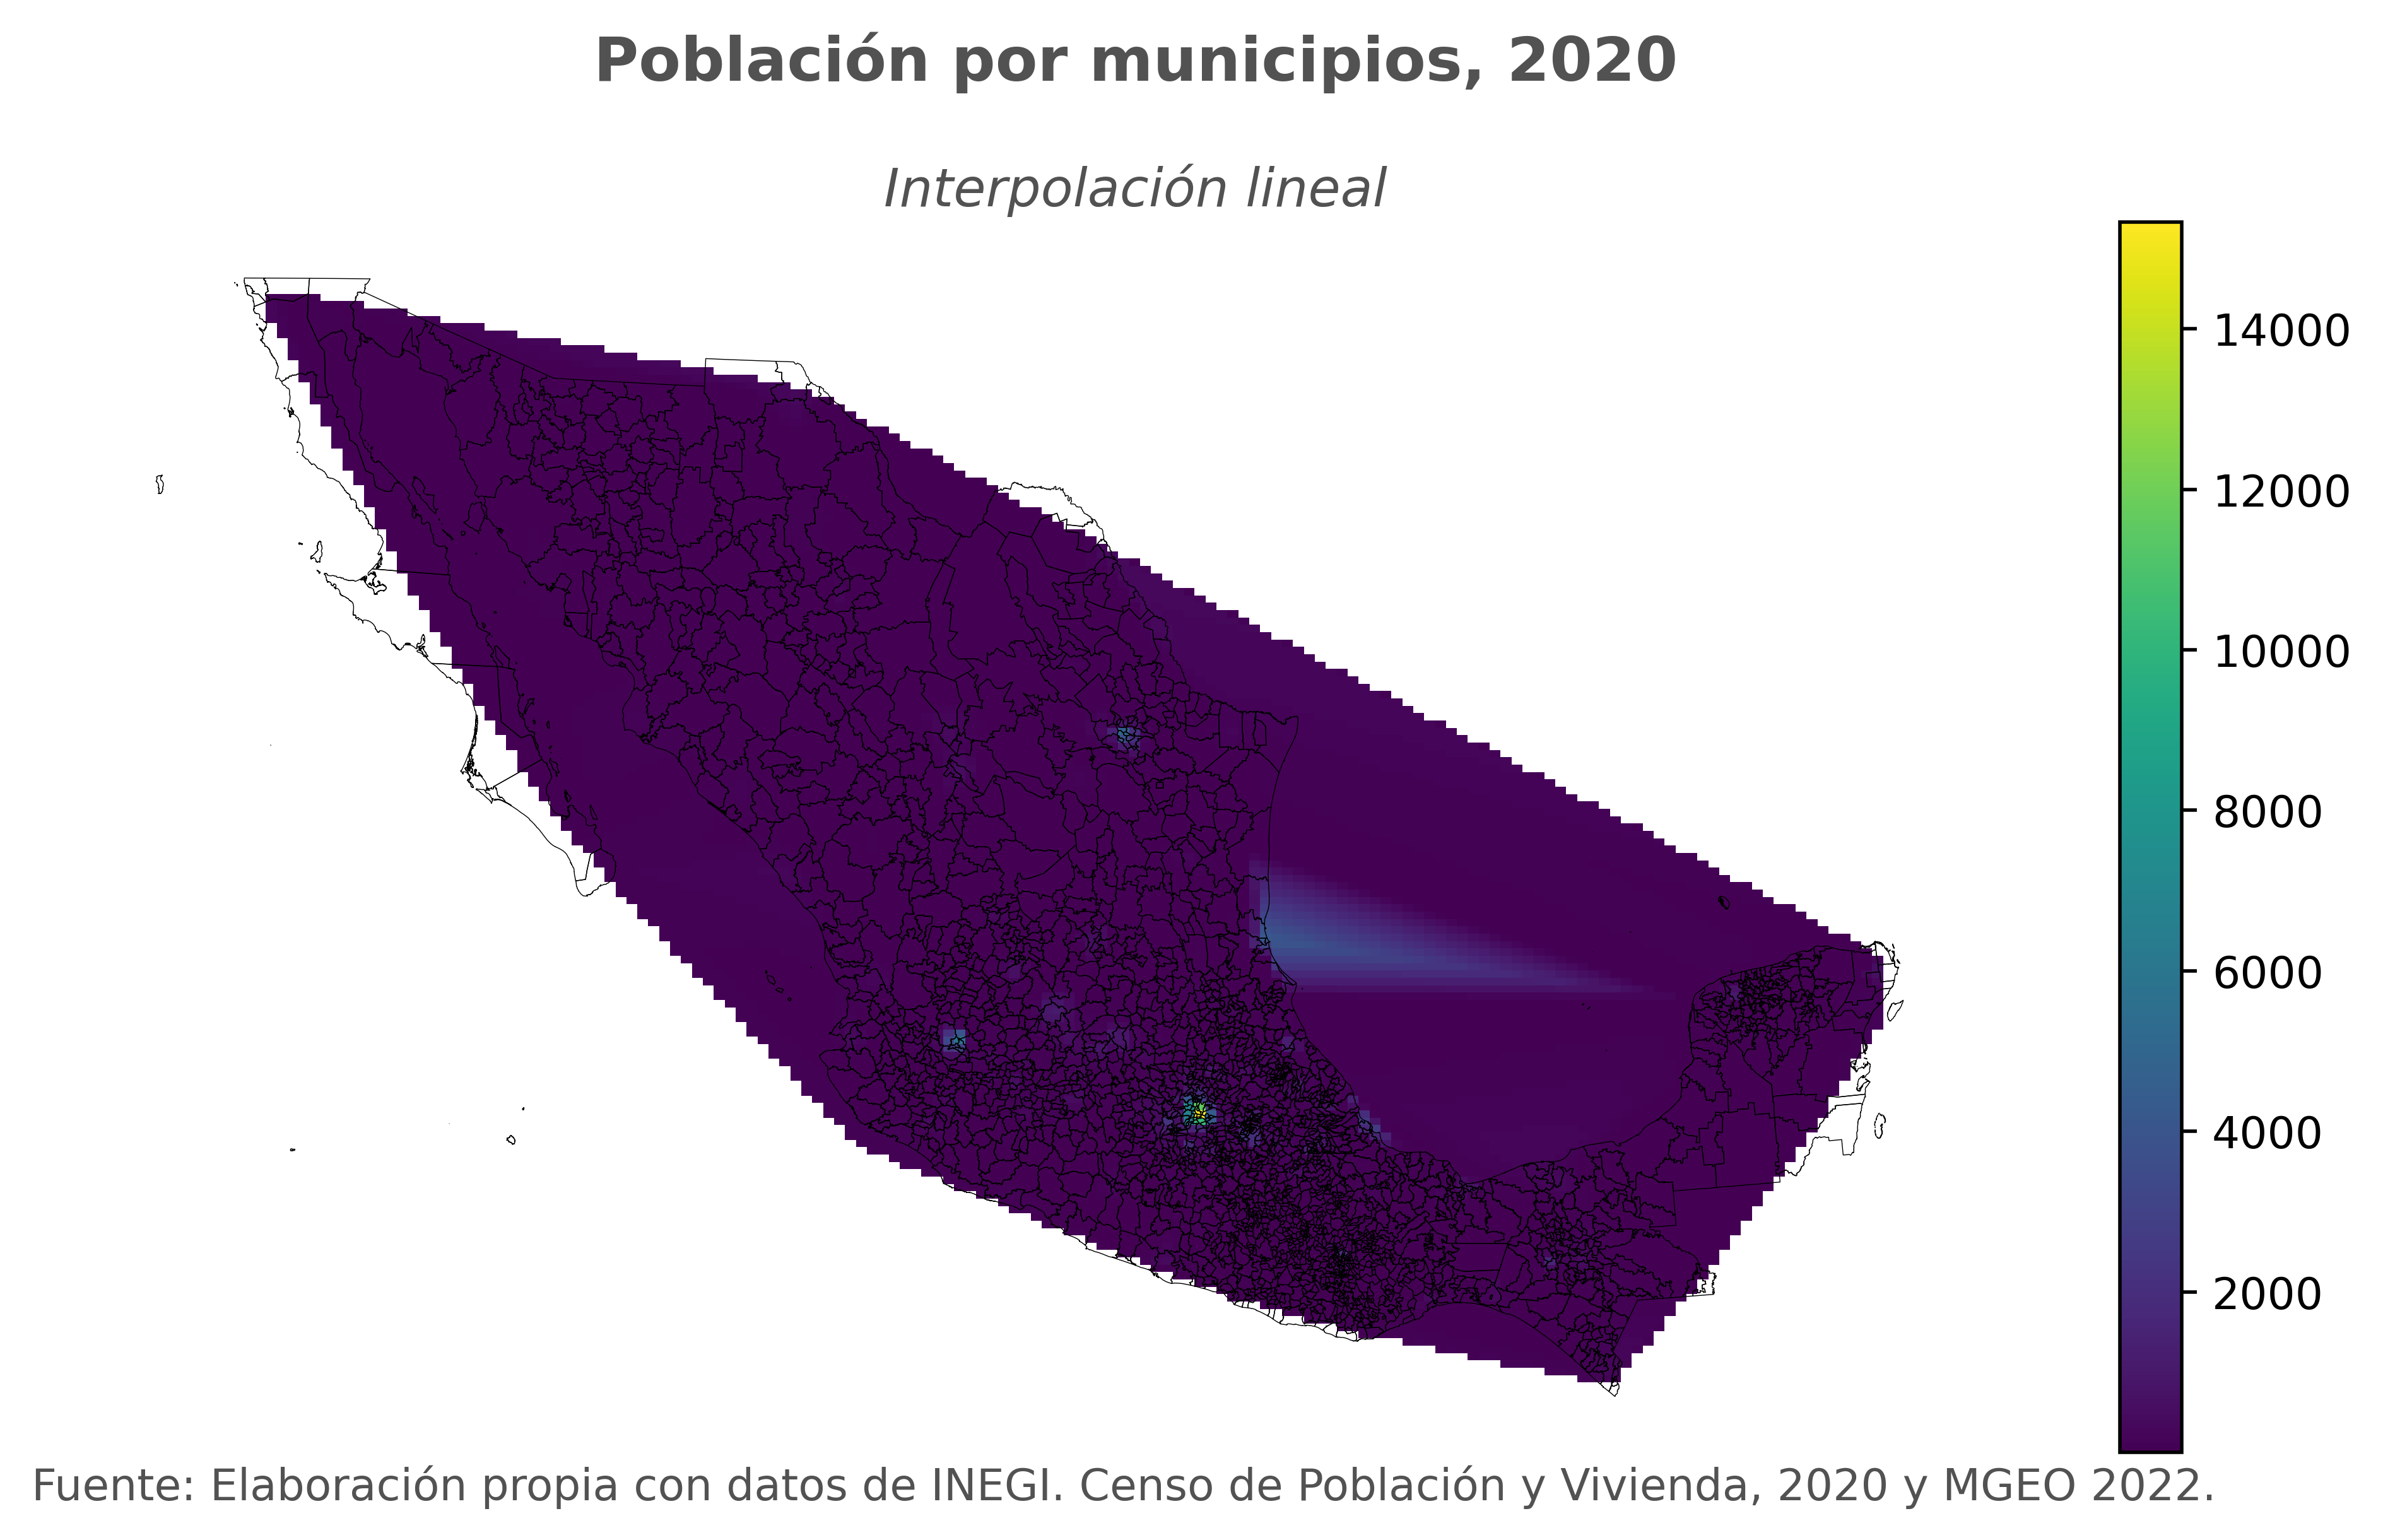

In [38]:
# Visualización de la interpolación

fig, ax = plt.subplots(1, figsize = (10,5), dpi = 500)


im = ax.imshow(
    z_grid,
    extent = (x.min(), x.max(), y.min(), y.max()),
    origin = 'lower'
)

Mapa.boundary.plot(ax=ax, linewidth = 0.2, color = 'black')
plt.colorbar(im, ax=ax)
plt.axis('off')
plt.figtext(0.4, 0.95, "Población por municipios, 2020",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Interpolación lineal",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos de INEGI. Censo de Población y Vivienda, 2020 y MGEO 2022.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.89])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Interpolación_Lineal.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')


In [41]:
# Validación cruzda

kf = KFold(n_splits = 5, shuffle = True, random_state = 123)
rmse=[]

for train, test in kf.split(x_obs):
  z_cv = griddata(
    points=(x_obs[train], y_obs[train]),
    values=z_obs[train],
    xi=(x_obs[test], y_obs[test]),
    method='nearest'
)

  rmse.append(
      np.sqrt(mean_squared_error(z_obs[test], z_cv))
  )

  print("RMSE promedio (Iterpolación lineal):", np.mean(rmse))

RMSE promedio (Iterpolación lineal): 489.03372075331004
RMSE promedio (Iterpolación lineal): 567.575671724834
RMSE promedio (Iterpolación lineal): 564.9729578207281
RMSE promedio (Iterpolación lineal): 542.8897476019715
RMSE promedio (Iterpolación lineal): 573.0754671632781


# Interpolación por Distancia Inversa (IDW)

In [42]:
# Función IDW

def idw_interpolation(x_obs, y_obs, z_obs,
                      x_pred, y_pred,
                      power=2, eps=1e-12):
    """
    IDW clásico
    """
    z_pred = np.zeros(len(x_pred))

    for i in range(len(x_pred)):
        dist = np.sqrt((x_obs - x_pred[i])**2 + (y_obs - y_pred[i])**2)
        dist = np.maximum(dist, eps)  # evitar división por cero

        weights = 1 / dist**power
        z_pred[i] = np.sum(weights * z_obs) / np.sum(weights)

    return z_pred

In [44]:
# Imputación de municipios sin población

z_pred_nan = idw_interpolation(
    x_obs, y_obs, z_obs,
    x_nan, y_nan,
    power=2
)

z_complete = z.copy()
z_complete[~mask_obs] = z_pred_nan

Mapa['POB_Km2_IDW'] = z_complete
Mapa['TIPO_DATO_IDW'] = np.where(mask_obs, 'Observado', 'Imputado')

Mapa[11:22]

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,ENTIDAD,MUN,POBTOT,area_km2,POB_KM2,POB_km2_lineal,Tipo_dato,POB_Km2_IDW,TIPO_DATO_IDW
11,02007,02,007,San Felipe,"MULTIPOLYGON (((1303929.109 2024125.252, 13040...",NaN,NaN,NaN,11063.217086,NaN,16.463268,Imputado,175.568848,Imputado
12,02003,02,003,Tecate,"POLYGON ((1108369.153 2349424.69, 1108488.649 ...",02,003,108440.0,2900.518701,37.386416,37.386416,Observado,37.386416,Observado
13,02004,02,004,Tijuana,"MULTIPOLYGON (((1058853.778 2337446.07, 105884...",02,004,1922523.0,1090.937294,1762.267190,1762.267190,Observado,1762.267190,Observado
14,02001,02,001,Ensenada,"MULTIPOLYGON (((1208711.465 1871972.953, 12087...",02,001,443807.0,13662.828278,32.482806,32.482806,Observado,32.482806,Observado
15,02006,02,006,San Quintín,"MULTIPOLYGON (((1313480.513 1831458.607, 13135...",02,006,117568.0,34097.244942,3.448021,3.448021,Observado,3.448021,Observado
16,02005,02,005,Playas de Rosarito,"POLYGON ((1076736.333 2336649.366, 1076738.335...",02,005,126890.0,513.145384,247.278849,247.278849,Observado,247.278849,Observado
17,02002,02,002,Mexicali,"MULTIPOLYGON (((1288348.994 2246381.522, 12884...",02,002,1049792.0,10078.266923,104.163941,104.163941,Observado,104.163941,Observado
18,03001,03,001,Comondú,"MULTIPOLYGON (((1493700.998 1422385.022, 14937...",03,001,73021.0,17532.625450,4.164864,4.164864,Observado,4.164864,Observado
19,03008,03,008,Los Cabos,"MULTIPOLYGON (((1694656.344 1227647.637, 16946...",03,008,351111.0,3517.574801,99.816214,99.816214,Observado,99.816214,Observado
20,03003,03,003,La Paz,"MULTIPOLYGON (((1677351.228 1380621.554, 16773...",03,003,292241.0,15279.285152,19.126615,19.126615,Observado,19.126615,Observado


In [45]:
# Dato de San Felipe, BC

175.568848*11063.217086

1942356.278962937

In [46]:
# Superficie interpolada


grid_x = np.linspace(x.min(), x.max(), 150)
grid_y = np.linspace(y.min(), y.max(), 150)
grid_X, grid_Y = np.meshgrid(grid_x, grid_y)

z_grid = idw_interpolation(
    x_obs, y_obs, z_obs,
    grid_X.ravel(),
    grid_Y.ravel(),
    power=2
).reshape(grid_X.shape)

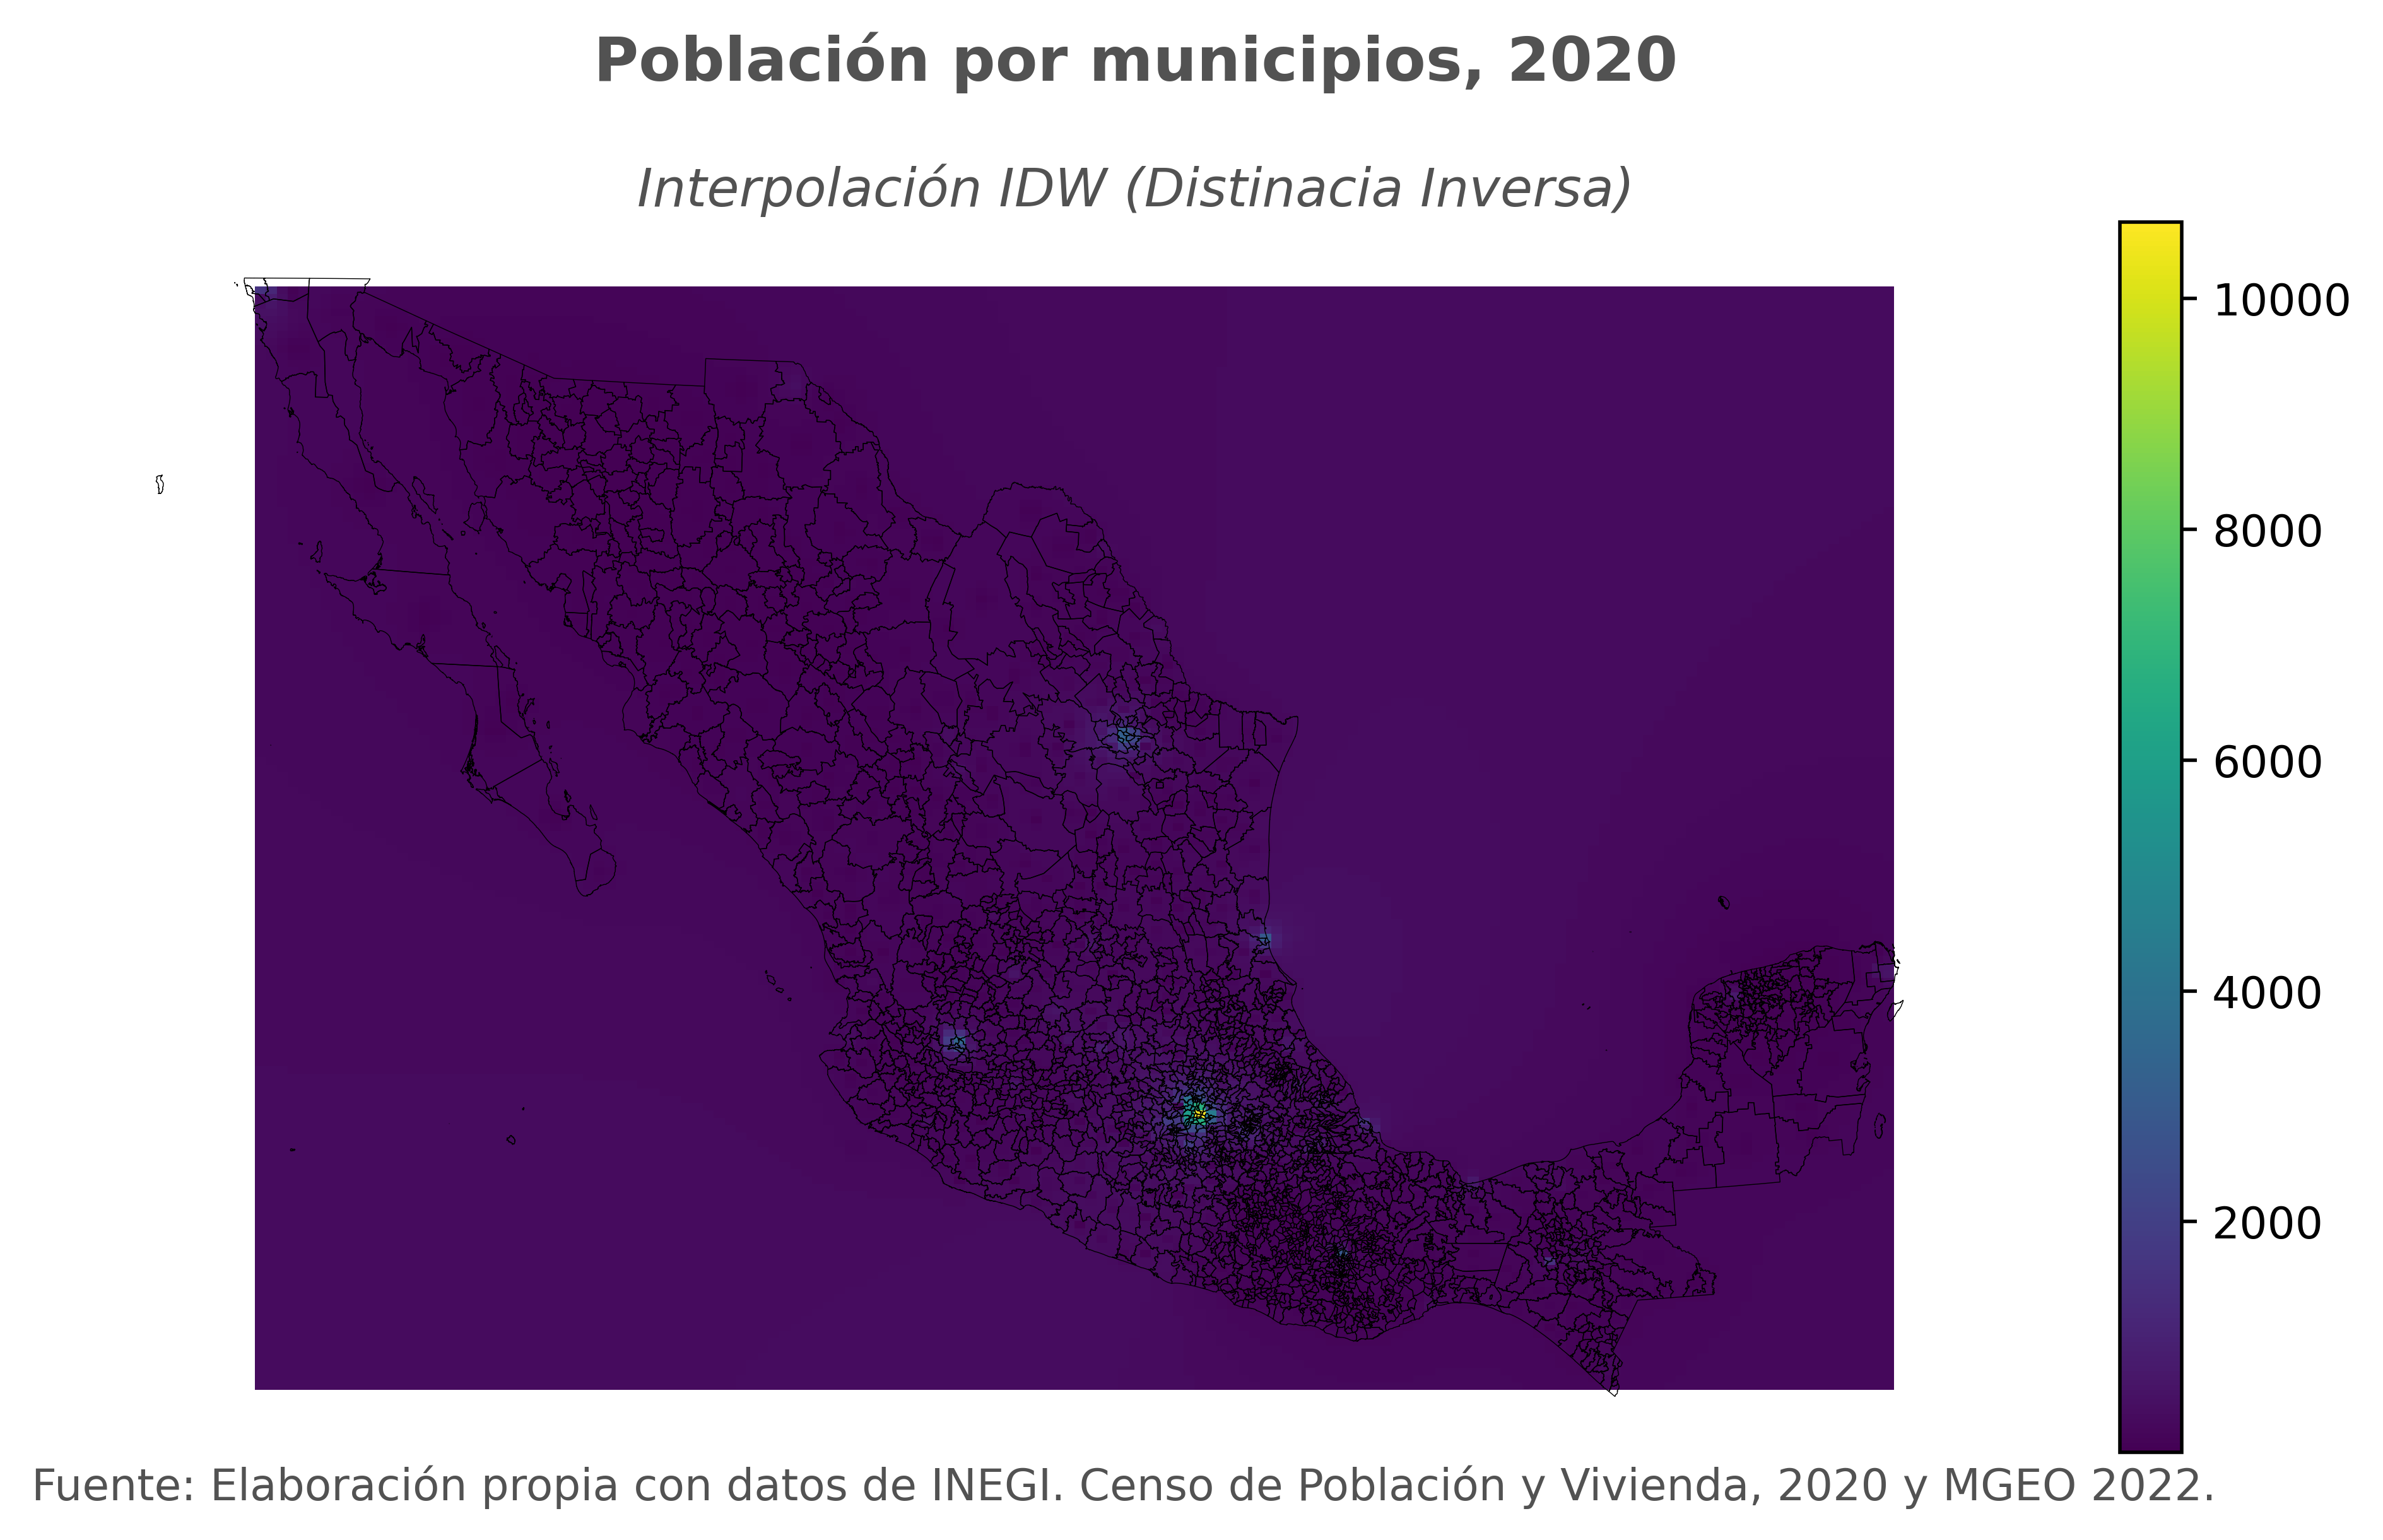

In [47]:

# Visualización

fig, ax = plt.subplots(1, figsize = (10,5), dpi = 500)

im = ax.imshow(
    z_grid,
    extent=(x.min(), x.max(), y.min(), y.max()),
    origin='lower'
)

Mapa.boundary.plot(ax=ax, linewidth=0.2, color='black')

plt.colorbar(im, ax=ax)
plt.axis('off')
plt.figtext(0.4, 0.95, "Población por municipios, 2020",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Interpolación IDW (Distinacia Inversa)",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos de INEGI. Censo de Población y Vivienda, 2020 y MGEO 2022.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.89])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Interpolación_IDW.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')
